# HW2 Playground

Fill in TODOs as you work through the assignment.
Implement the required sections in `model.py`, and use this notebook to orchestrate and run your solution.

In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from hw2_loader import HW2DataLoader
from model import GradientBoostingModel

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
# TODO: Load both datasets
loader = HW2DataLoader()

# Heart disease dataset
heart_path = Path('../data/heart.csv')
X_heart, y_heart = loader.get_heart_disease_data(csv_path=heart_path)
print(X_heart.shape, y_heart.value_counts().to_dict())

# Cancer genomics dataset
cancer_path = Path('../data/cancer_genomics.csv')
labels_path = Path('../data/labels_cancer_genomics.csv')
X_cancer, y_cancer = loader.get_cancer_genomics_data(
    csv_path=cancer_path, labels_path=labels_path
)

print(X_cancer.shape, y_cancer.value_counts().to_dict())

Successfully loaded heart disease data with 1025 rows
(1025, 13) {1: 526, 0: 499}
(801, 5479) {'BRCA': 300, 'KIRC': 146, 'LUAD': 141, 'PRAD': 136, 'COAD': 78}


------------------------------
Heart Dataset EDA
------------------------------
Missing Values: 0

Target Distribution: 

target
1    526
0    499
Name: count, dtype: int64



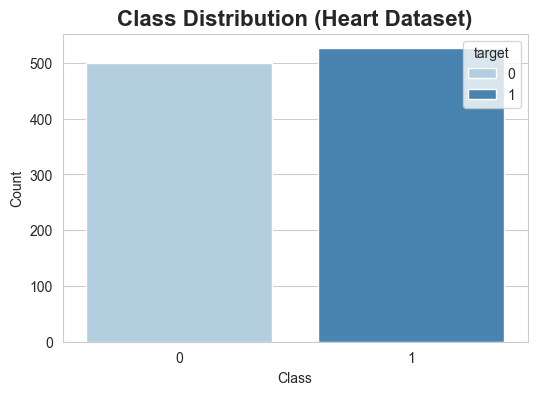

Numeric Features: 13
Categorical Features: 0


------------------------------
Cancer Dataset EDA
------------------------------
Missing Values: 0

Target Distribution: 

Class
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64



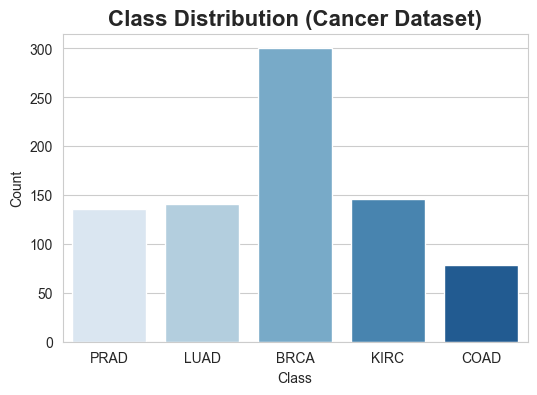

Numeric Features: 5479
Categorical Features: 0


In [19]:
#####################
# HEART DATASET EDA #
#####################
print('-' * 30)
print('Heart Dataset EDA')
print('-' * 30)

print(f'Missing Values: {X_heart.isnull().sum().sum()}')
print()
print(f'Target Distribution: \n\n{y_heart.value_counts()}')
print()

# CLASS IMBALANCE
plt.figure(figsize = (6, 4))
sns.countplot(x = y_heart, palette = "Blues", hue = y_heart)
plt.title("Class Distribution (Heart Dataset)", fontsize = 16, fontweight = "bold")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


numeric_features = len(X_heart.select_dtypes(include = [np.number]).columns)
categorical_features = len(X_heart.select_dtypes(exclude = [np.number]).columns)

print(f'Numeric Features: {numeric_features}')
print(f'Categorical Features: {categorical_features}')

print()
print()

######################
# CANCER DATASET EDA #
######################
print('-' * 30)
print('Cancer Dataset EDA')
print('-' * 30)

print(f'Missing Values: {X_cancer.isnull().sum().sum()}')
print()
print(f'Target Distribution: \n\n{y_cancer.value_counts()}')
print()

# CLASS IMBALANCE
plt.figure(figsize = (6, 4))
sns.countplot(x = y_cancer, palette = "Blues", hue = y_cancer)
plt.title("Class Distribution (Cancer Dataset)", fontsize = 16, fontweight = "bold")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


numeric_features = len(X_cancer.select_dtypes(include = [np.number]).columns)
categorical_features = len(X_cancer.select_dtypes(exclude = [np.number]).columns)

print(f'Numeric Features: {numeric_features}')
print(f'Categorical Features: {categorical_features}')

In [32]:
# TODO: Initialize your model (adjust params)
model = GradientBoostingModel(
    task = 'classification',
    max_depth = 3,
    learning_rate = 0.1,
    n_estimators = 100, 
    use_scaler = True,
    random_state = 42
)

In [33]:
# TODO: Train/test split + fit (heart)

# check for & REMOVE duplicates
print(X_heart.duplicated().sum())

# heart_df = X_heart.copy()
# heart_df["target"] = y_heart
# heart_df = heart_df.drop_duplicates()
# X_heart = heart_df.drop(columns = ["target"])
# y_heart = heart_df["target"]

# print(X_heart.duplicated().sum())
# print(X_heart.shape)

X_train, X_test, y_train, y_test = model.train_test_split(X_heart, y_heart, test_size = 0.3, random_state = 42)
model.fit(X_train, y_train)

723


In [34]:
# TODO: Evaluate (heart)
metrics = model.evaluate(X_test, y_test)

# print metrics
print(metrics)

{'accuracy': 0.9512987012987013, 'precision': 0.9466666666666667, 'recall': 0.9530201342281879, 'f1': 0.9498327759197325, 'roc_auc': 0.9889831581613271}


In [35]:
# TODO: Cross-validation (heart)
cv_results = model.cross_validate(X_heart, y_heart)

# print metrics
print(cv_results)

{'accuracy': {'mean': np.float64(0.9639024390243902), 'std': np.float64(0.008505168670323273)}, 'precision_weighted': {'mean': np.float64(0.9643424701561806), 'std': np.float64(0.008616866484189942)}, 'recall_weighted': {'mean': np.float64(0.9639024390243902), 'std': np.float64(0.008505168670323273)}, 'f1_weighted': {'mean': np.float64(0.9638967588246292), 'std': np.float64(0.008501378183559255)}, 'roc_auc_ovr': {'mean': np.float64(0.9907606523455581), 'std': np.float64(0.008130050695375217)}}


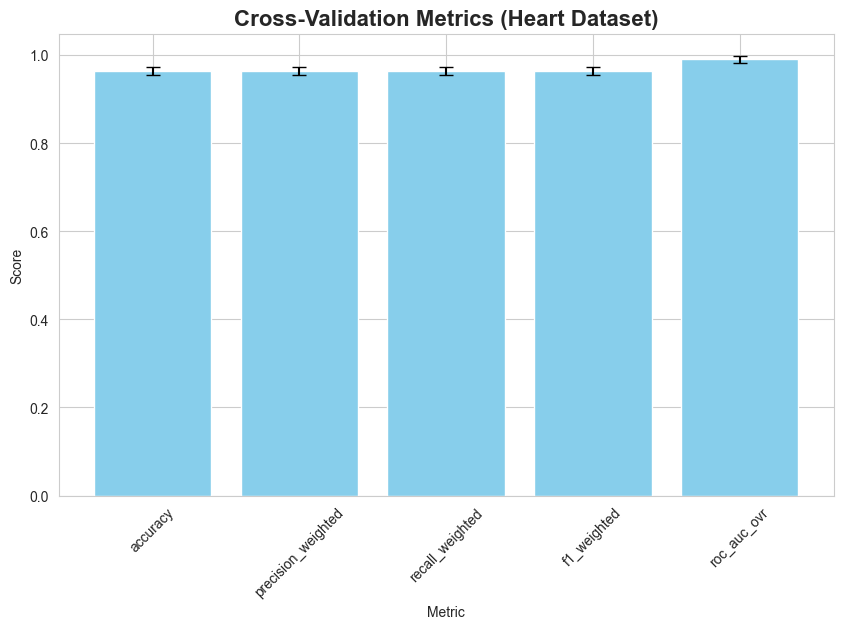

In [36]:
# CROSS VALIDATION RESULTS
metrics = ["accuracy", "precision_weighted", "recall_weighted", "f1_weighted", "roc_auc_ovr"]

means = [cv_results[metric]["mean"] for metric in metrics]
std = [cv_results[metric]["std"] for metric in metrics]

plt.figure(figsize = (10, 6))
plt.bar(metrics, means, yerr = std, capsize = 5, color = "skyblue")
plt.ylabel("Score")
plt.title("Cross-Validation Metrics (Heart Dataset)", fontsize = 16, fontweight = "bold")
plt.xlabel("Metric")
plt.xticks(rotation = 45)
plt.show()

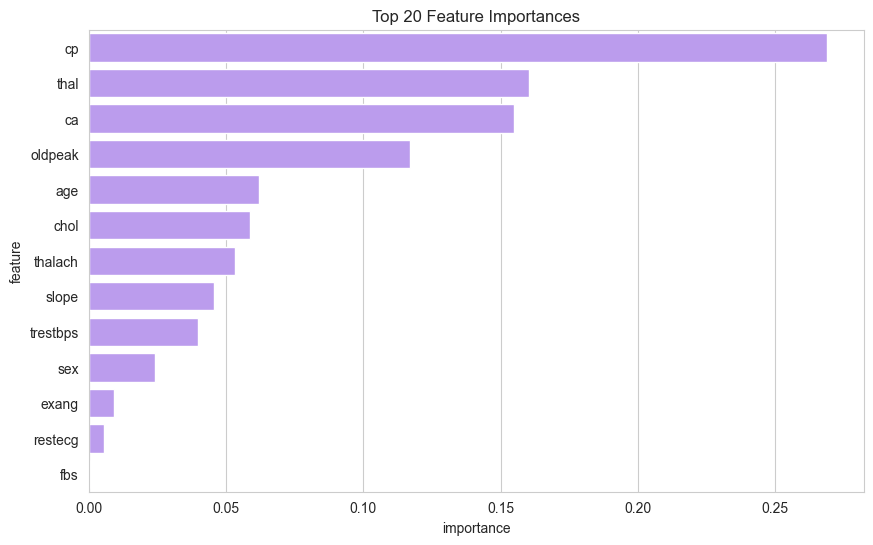

    feature  importance
0        cp     0.26870
1      thal     0.16046
2        ca     0.15507
3   oldpeak     0.11706
4       age     0.06200
5      chol     0.05889
6   thalach     0.05332
7     slope     0.04556
8  trestbps     0.03977
9       sex     0.02421


In [37]:
# TODO: Feature importance (heart)
feature_importance = model.get_feature_importance(plot = True)
print(feature_importance.head(10))

In [39]:
# TODO: Hyperparameter tuning (heart)
param_grid = {
    'max_depth': [2, 3, 4],
    'n_estimators': [10, 50, 100],
    'learning_rate': [0.01, 0.1, 1],
}

tuning_results = model.tune_hyperparameters(X_heart, y_heart, param_grid, cv = 3)
print(tuning_results['best_params'])
print(tuning_results['best_score'])


    Learning Rate  Max Depth  Number of Estimators  Mean CV Score  \
25        1.00000          4                    50        0.99162   
24        1.00000          4                    10        0.99057   
26        1.00000          4                   100        0.98795   
23        1.00000          3                   100        0.98695   
16        0.10000          4                    50        0.98655   

    Std CV Score  
25       0.00896  
24       0.00860  
26       0.00890  
23       0.00992  
16       0.00889  

{'learning_rate': 1, 'max_depth': 4, 'n_estimators': 50}
0.9916173786053304


In [27]:
# TASK: train a gradient boosted on both datasets with and without standardization

# WITH STANDARDIZATION
standardized_model = GradientBoostingModel(
    task = 'classification',
    max_depth = 3,
    learning_rate = 0.1,
    n_estimators = 100, 
    use_scaler = True,
)

# WITHOUT STANDARDIZATION
non_standardized_model = GradientBoostingModel(
    task = 'classification',
    max_depth = 3,
    learning_rate = 0.1,
    n_estimators = 100, 
    use_scaler = False,
)

# TRAIN/TEST SPLIT
X_train_standardized, X_test_standardized, y_train_standardized, y_test_standardized = standardized_model.train_test_split(X_heart, y_heart, test_size = 0.3, random_state = 42)
X_train_non_standardized, X_test_non_standardized, y_train_non_standardized, y_test_non_standardized = non_standardized_model.train_test_split(X_heart, y_heart, test_size = 0.3, random_state = 42)

# FIT
standardized_model.fit(X_train_standardized, y_train_standardized)
non_standardized_model.fit(X_train_non_standardized, y_train_non_standardized)

# EVALUATE
standardized_metrics = standardized_model.evaluate(X_test_standardized, y_test_standardized)
non_standardized_metrics = non_standardized_model.evaluate(X_test_non_standardized, y_test_non_standardized)

print(standardized_metrics)
print(non_standardized_metrics)

{'accuracy': 0.9512987012987013, 'precision': 0.9466666666666667, 'recall': 0.9530201342281879, 'f1': 0.9498327759197325, 'roc_auc': 0.9889831581613271}
{'accuracy': 0.9512987012987013, 'precision': 0.9466666666666667, 'recall': 0.9530201342281879, 'f1': 0.9498327759197325, 'roc_auc': 0.9889831581613271}


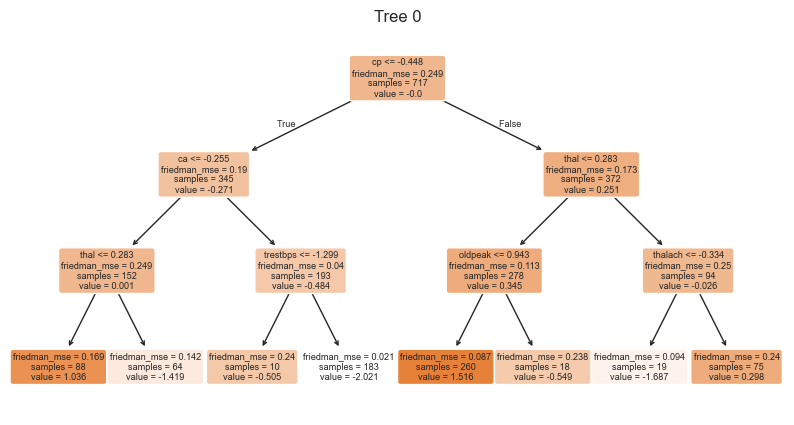

In [28]:
standardized_model.plot_tree(figsize = (10, 5))


    Learning Rate  Max Depth  Number of Estimators  Mean CV Score  \
13            0.1          3                    50       0.999851   
14            0.1          3                   100       0.999847   
11            0.1          2                   100       0.999837   
9             0.1          2                    10       0.999825   
10            0.1          2                    50       0.999824   

    Std CV Score  
13      0.000074  
14      0.000107  
11      0.000145  
9       0.000084  
10      0.000135  

Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}
Best Score: 0.9998511123201976

Metrics: {'accuracy': 0.9875518672199171, 'precision': 0.9879534198902422, 'recall': 0.9875518672199171, 'f1': 0.9875085544487952, 'roc_auc': 0.9936393625860831}


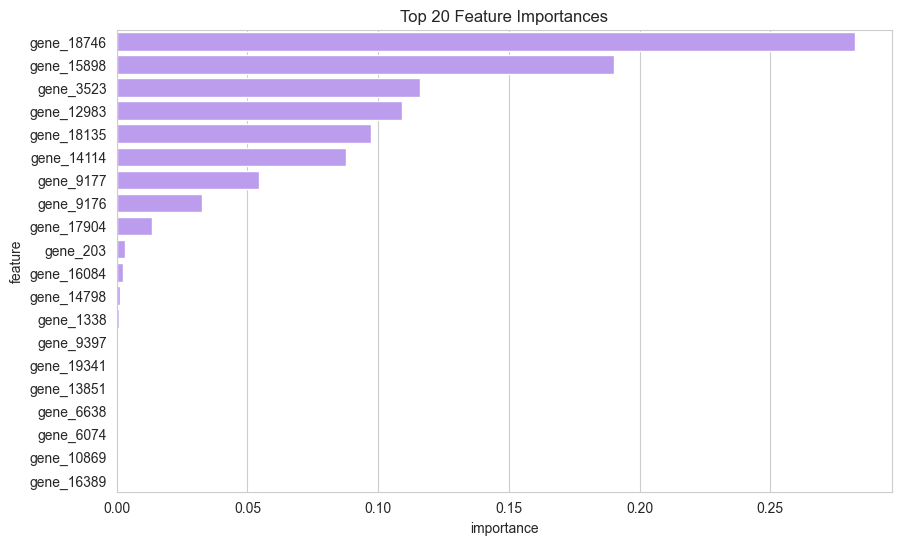

      feature  importance
0  gene_18746     0.28230
1  gene_15898     0.19030
2   gene_3523     0.11609
3  gene_12983     0.10924
4  gene_18135     0.09738
5  gene_14114     0.08785
6   gene_9177     0.05428
7   gene_9176     0.03268
8  gene_17904     0.01342
9    gene_203     0.00331


In [29]:
# TODO: Train/evaluate on cancer dataset (multi-class)
# WITH STANDARDIZATION

# print(X_cancer.duplicated().sum()) => 0 DUPLICATES

cancer_model = GradientBoostingModel(
    task = 'classification',
    max_depth = 3,
    learning_rate = 0.1,
    n_estimators = 100, 
    use_scaler = True,
)

# TUNE HYPERPARAMETERS
param_grid = {
    'max_depth': [2, 3, 4],
    'n_estimators': [10, 50, 100],
    'learning_rate': [0.01, 0.1, 1],
}

tuning_results = cancer_model.tune_hyperparameters(X_cancer, y_cancer, param_grid, cv = 3, scoring = "roc_auc_ovr")
print(f'Best Params: {tuning_results["best_params"]}')
print(f'Best Score: {tuning_results["best_score"]}')
print()

best_params = tuning_results['best_params']

cancer_model = GradientBoostingModel(task = "classification", **best_params, use_scaler = True)

# TRAIN/TEST SPLIT
X_train, X_test, y_train, y_test = cancer_model.train_test_split(X_cancer, y_cancer, test_size = 0.3, random_state = 42, stratify = y_cancer)

# FIT
cancer_model.fit(X_train, y_train)

# EVALUATE
metrics = cancer_model.evaluate(X_test, y_test)
print(f'Metrics: {metrics}')

# FEATURE IMPORTANCE
feature_importance = cancer_model.get_feature_importance(plot = True)

pd.options.display.float_format = '{:.5f}'.format
print(feature_importance.head(10))


    Learning Rate  Max Depth  Number of Estimators  Mean CV Score  \
13        0.10000          3                    50        0.99985   
14        0.10000          3                   100        0.99985   
11        0.10000          2                   100        0.99984   
9         0.10000          2                    10        0.99983   
10        0.10000          2                    50        0.99982   

    Std CV Score  
13       0.00007  
14       0.00011  
11       0.00014  
9        0.00008  
10       0.00014  

Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}
Best Score: 0.9998511123201976
Metrics: {'accuracy': 0.9875518672199171, 'precision': 0.9879534198902422, 'recall': 0.9875518672199171, 'f1': 0.9875085544487952, 'roc_auc': 0.9936393625860831}


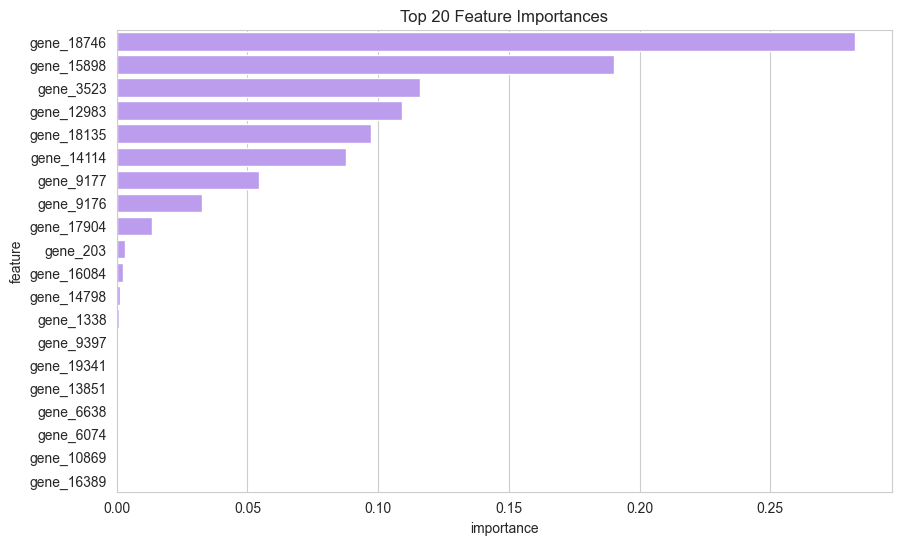

      feature  importance
0  gene_18746     0.28230
1  gene_15898     0.19030
2   gene_3523     0.11609
3  gene_12983     0.10924
4  gene_18135     0.09738
5  gene_14114     0.08785
6   gene_9177     0.05428
7   gene_9176     0.03268
8  gene_17904     0.01342
9    gene_203     0.00331


In [43]:
# WITHOUT STANDARDIZATION

cancer_model = GradientBoostingModel(
    task = 'classification',
    max_depth = 3,
    learning_rate = 0.1,
    n_estimators = 100, 
    use_scaler = False,
)

# TUNE HYPERPARAMETERS
param_grid = {
    'max_depth': [2, 3, 4],
    'n_estimators': [10, 50, 100],
    'learning_rate': [0.01, 0.1, 1],
}

tuning_results = cancer_model.tune_hyperparameters(X_cancer, y_cancer, param_grid, cv = 3, scoring = "roc_auc_ovr")
print(f'Best Params: {tuning_results["best_params"]}')
print(f'Best Score: {tuning_results["best_score"]}')

best_params = tuning_results['best_params']

cancer_model = GradientBoostingModel(task = "classification", **best_params, use_scaler = False)

# TRAIN/TEST SPLIT
X_train, X_test, y_train, y_test = cancer_model.train_test_split(X_cancer, y_cancer, test_size = 0.3, random_state = 42, stratify = y_cancer)

# FIT
cancer_model.fit(X_train, y_train)

# EVALUATE
metrics = cancer_model.evaluate(X_test, y_test)
print(f'Metrics: {metrics}')

# FEATURE IMPORTANCE
feature_importance = cancer_model.get_feature_importance(plot = True)

pd.options.display.float_format = '{:.5f}'.format
print(feature_importance.head(10))

Metrics: {'accuracy': 0.9875518672199171, 'precision': 0.9879534198902422, 'recall': 0.9875518672199171, 'f1': 0.9875085544487952, 'roc_auc': 0.9937350792647142}


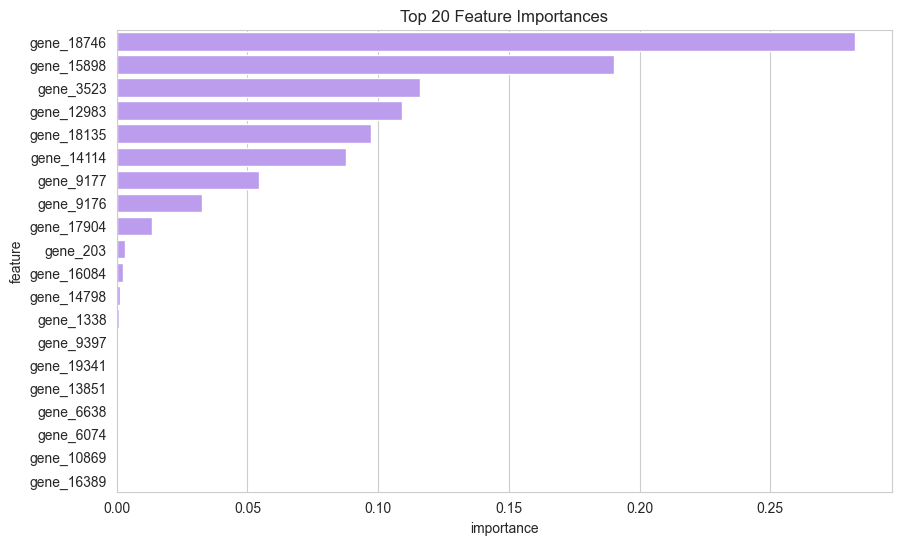

      feature  importance
0  gene_18746     0.28230
1  gene_15898     0.19030
2   gene_3523     0.11609
3  gene_12983     0.10924
4  gene_18135     0.09738
5  gene_14114     0.08785
6   gene_9177     0.05428
7   gene_9176     0.03268
8  gene_17904     0.01342
9    gene_203     0.00331


In [50]:
# DEFAULT MODEL (no tuning beforehand so I can compare to the heart model)
cancer_model = GradientBoostingModel(
    task = 'classification',
    max_depth = 3,
    learning_rate = 0.1,
    n_estimators = 100, 
    use_scaler = True,
)

# TRAIN/TEST SPLIT
X_train, X_test, y_train, y_test = cancer_model.train_test_split(X_cancer, y_cancer, test_size = 0.3, random_state = 42, stratify = y_cancer)

# FIT
cancer_model.fit(X_train, y_train)

# EVALUATE
metrics = cancer_model.evaluate(X_test, y_test)
print(f'Metrics: {metrics}')

# FEATURE IMPORTANCE
feature_importance = cancer_model.get_feature_importance(plot = True)

pd.options.display.float_format = '{:.5f}'.format
print(feature_importance.head(10))

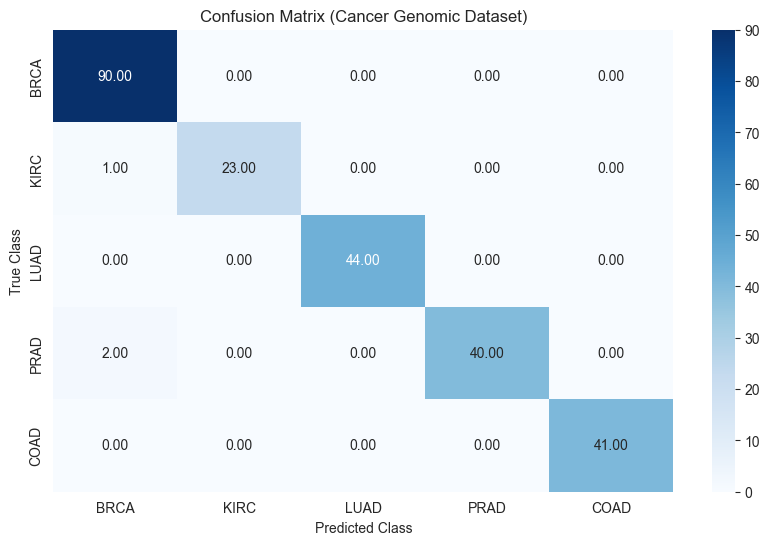

In [52]:
from sklearn.metrics import confusion_matrix

y_pred_cancer = cancer_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_cancer)
# error for mix of label types before
cm_normalized = cm.astype('float') / cm.sum(axis = 1)[:, np.newaxis]

fig, ax = plt.subplots(figsize = (10, 6))
sns.heatmap(cm, annot = True, fmt = ".2f", cmap = "Blues", xticklabels = ['BRCA', 'KIRC', 'LUAD', 'PRAD', 'COAD'], yticklabels = ['BRCA', 'KIRC', 'LUAD', 'PRAD', 'COAD'], ax = ax)
ax.set_title("Confusion Matrix (Cancer Genomic Dataset)")
ax.set_xlabel("Predicted Class")
ax.set_ylabel("True Class")
plt.show()

{'accuracy': {'mean': np.float64(0.986273291925466), 'std': np.float64(0.006104854691187139)}, 'precision_weighted': {'mean': np.float64(0.9868152327228124), 'std': np.float64(0.005793548662222201)}, 'recall_weighted': {'mean': np.float64(0.986273291925466), 'std': np.float64(0.006104854691187139)}, 'f1_weighted': {'mean': np.float64(0.9861598652342988), 'std': np.float64(0.00618656222889626)}, 'roc_auc_ovr': {'mean': np.float64(0.9998028291878669), 'std': np.float64(0.0002334600515504683)}}


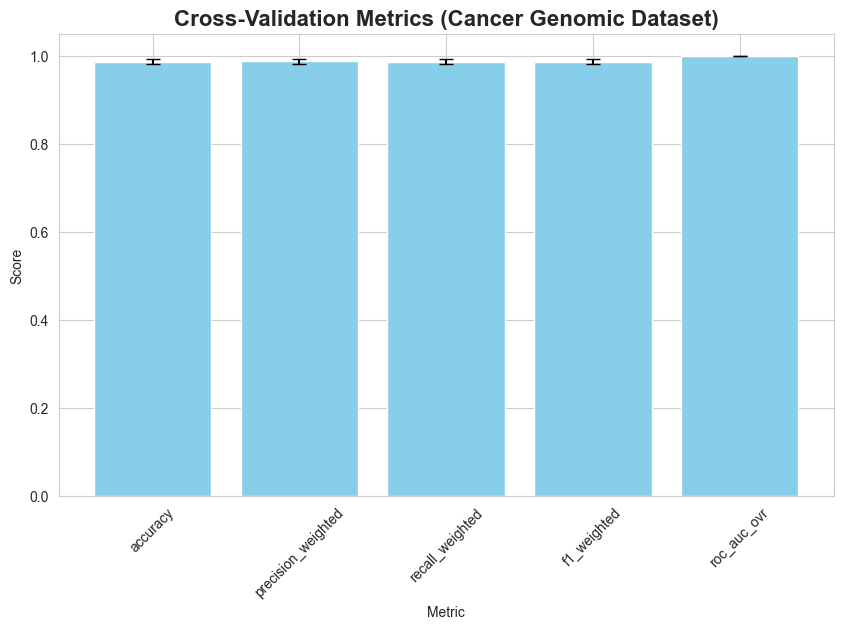

In [46]:
# TASK: evlaute w/ k-fold cross validation in multi-class context
cv_results = cancer_model.cross_validate(X_cancer, y_cancer)
print(cv_results)

# CROSS VALIDATION RESULTS
metrics = ["accuracy", "precision_weighted", "recall_weighted", "f1_weighted", "roc_auc_ovr"]

means = [cv_results[metric]["mean"] for metric in metrics]
std = [cv_results[metric]["std"] for metric in metrics]

plt.figure(figsize = (10, 6))
plt.bar(metrics, means, yerr = std, capsize = 5, color = "skyblue")
plt.ylabel("Score")
plt.title("Cross-Validation Metrics (Cancer Genomic Dataset)", fontsize = 16, fontweight = "bold")
plt.xlabel("Metric")
plt.xticks(rotation = 45)
plt.show()

In [ ]:
# TASK: model architecture from HW1 + perform feature selection/importance
import sys
from pathlib import Path
sys.path.append(str(Path('../../../homework-1-ashleywoertz').resolve()))
from homework1.src.model import GenomicAgeRegressor
from homework1.src.hw1_loader import HW1DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# error b/c its a regresser model trying to do classification so 
# converting the labels to number values and do it that way

encoder = LabelEncoder()
y_nums = encoder.fit_transform(y_cancer)

X_train, X_test, y_train, y_test = train_test_split(X_cancer, y_nums, test_size = 0.3, random_state = 42)

# LASSO MODEL
regressor = GenomicAgeRegressor(model_type = 'lasso', random_state = 42, alpha = 0.01)

# fitting on full dataset
regressor.fit(X_train, y_train)
metrics = regressor.evaluate(X_test, y_test)
print(f'LASSO Model Metrics (Full Dataset): {metrics}')

# non-zero coefficients
k = 100
coefficients = regressor.model.coef_

lasso_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": coefficients
})

lasso_importance = lasso_importance[lasso_importance["importance"] != 0]
lasso_importance["abs_coefficient"] = lasso_importance["importance"].abs()
lasso_importance["percent_importance"] = (100 * lasso_importance["abs_coefficient"] / lasso_importance["abs_coefficient"].sum())
lasso_importance = lasso_importance.sort_values("abs_coefficient", ascending = False)
print("Top 10 LASSO Features:")
print(lasso_importance.head(10))
print()

selected_features = X_train.columns[coefficients != 0]
topk = selected_features[:k]

# train HW1 model on top k features
topk_regressor = GenomicAgeRegressor(model_type = 'lasso', selected_features = topk, random_state = 42)
topk_regressor.fit(X_train, y_train)
topk_metrics = topk_regressor.evaluate(X_test, y_test)
print(f'LASSO Model Metrics (Top {k} LASSO Features): {topk_metrics}')

# TASK: train a GB model and get top k features
gb_model = GradientBoostingModel(
    task = 'classification',
    max_depth = 3,
    learning_rate = 0.1,
    n_estimators = 100, 
    use_scaler = True,
)

gb_model.fit(X_train, y_train)
gb_feature_importance = gb_model.get_feature_importance(plot = False)
top_gb_features = gb_feature_importance.sort_values("importance", ascending = False).head(k).feature
print(f'Top {k} GB Model Features: {top_gb_features}')

# TASK: train HW1 model on top k features from GB model
topk_regressor = GenomicAgeRegressor(model_type = 'lasso', selected_features = top_gb_features, random_state = 42)
topk_regressor.fit(X_train, y_train)
topk_metrics = topk_regressor.evaluate(X_test, y_test)
print(f'LASSO Model Metrics (Using Top {k} GB Model Features): {topk_metrics}')

LASSO Model Metrics (Full Dataset): {'mse': 0.0475144670896582, 'rmse': np.float64(0.21797813443017217), 'r2': 0.9797943493700803, 'mae': 0.15336928411349604}
Top 10 LASSO Features:
         feature  importance  abs_coefficient  percent_importance
4908  gene_17801    0.153132         0.153132            5.192864
3462  gene_11903    0.102503         0.102503            3.475973
3394  gene_11576   -0.092328         0.092328            3.130934
1622   gene_5578   -0.074390         0.074390            2.522649
964    gene_3448    0.074045         0.074045            2.510940
2385   gene_8032   -0.064447         0.064447            2.185458
331    gene_1096    0.060655         0.060655            2.056877
4612  gene_16372    0.057755         0.057755            1.958526
1991   gene_6748    0.056136         0.056136            1.903622
2060   gene_6976   -0.053152         0.053152            1.802442

LASSO Model Metrics (Top 100 LASSO Features): {'mse': 2.035718156004717, 'rmse': np.float64